# PRÁCTICA UNO: ACTIVIDAD RNN BÁSICA VANILLA

**Curso:** Inteligencia Artificial  
**Docente:** Eduardo Alcaraz  
**Fecha de Entrega:** Junio 2026  

--- 
## Objetivo
Comprender el funcionamiento matemático e intuitivo de una Red Neuronal Recurrente (RNN) tipo Vanilla, analizando el comportamiento de su estado oculto y memoria a corto plazo, así como el desvanecimiento de la información en función de sus parámetros internos.

## El Termómetro de las Emociones (Una Vanilla RNN)

Imagina que tú eres una red neuronal recurrente y tienes que adivinar tu estado de ánimo al final del día. A diferencia de un modelo normal que solo ve lo que te pasa hoy, tú tienes memoria. Tu cerebro junta dos cosas para decidir cómo te sientes: lo que te pasó hoy y cómo te sentías ayer al irte a dormir.

Al final del día, tu humor no depende solo de hoy. Si ayer tuviste un día increíble, aunque hoy te pase algo malo, no te vas a poner triste de golpe porque tu memoria de ayer te ayuda a aguantar. Matemáticamente esto se escribe como:

$$Estado de Hoy = Evento de Hoy + (Fracción \cdot Estado de Ayer)$$

La fracción representa qué tanta memoria te queda del día anterior. El problema con este modelo es que si solo guardas la mitad de lo que sentías ayer (el 50%), conforme pasan los días vas a olvidar todo muy rápido. Para el fin de semana ya no te vas a acordar de lo feliz que estabas el lunes si no te pasa nada nuevo en el camino.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar estilo visual para gráficos premium
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 16
})

class VanillaRNN:
    """
    Clase que simula una Vanilla RNN básica para modelar el estado oculto
    basado en entradas diarias y un peso de recurrencia de memoria.
    """
    def __init__(self, w_hh=0.5):
        self.w_hh = w_hh
        
    def simular_dias(self, eventos, h_inicial=0.0):
        """
        Simula la evolución de los estados ocultos día a día.
        
        Parámetros:
        eventos (list o np.array): Lista de estímulos diarios (x_t)
        h_inicial (float): Estado oculto inicial (h_0)
        
        Retorna:
        np.array: Estados ocultos de cada día (h_t)
        """
        num_dias = len(eventos)
        estados = np.zeros(num_dias + 1)
        estados[0] = h_inicial
        
        for t in range(num_dias):
            # Ecuación básica de la RNN recurrente
            estados[t + 1] = eventos[t] + self.w_hh * estados[t]
            
        # Devolvemos omitiendo el estado h_0 para alinearlo con los días 1 a N
        return estados[1:]

# Inicializar modelo básico con w_hh = 0.5 (retención del 50%)
rnn = VanillaRNN(w_hh=0.5)
dias = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes']

## Misión 1: El Lunes Increíble (Demostrando el Desvanecimiento)

El objetivo de esta misión es observar cómo un evento sumamente positivo y fuerte en el pasado se olvida gradualmente con el transcurso de los días si no se presentan nuevos estímulos intermedios. Para ello, simulamos que el Lunes (Día 1) ocurre un suceso excelente con un valor de entrada de más diez, mientras que del Martes al Viernes (Días 2 al 5) transcurren jornadas completamente rutinarias sin estímulos adicionales, representadas con entradas de cero.

=== EVOLUCIÓN DEL ESTADO DE ÁNIMO - MISIÓN 1 ===
Lunes: Evento = +10.0 | Estado Final = 10.0000
Martes: Evento = +0.0 | Estado Final = 5.0000
Miércoles: Evento = +0.0 | Estado Final = 2.5000
Jueves: Evento = +0.0 | Estado Final = 1.2500
Viernes: Evento = +0.0 | Estado Final = 0.6250


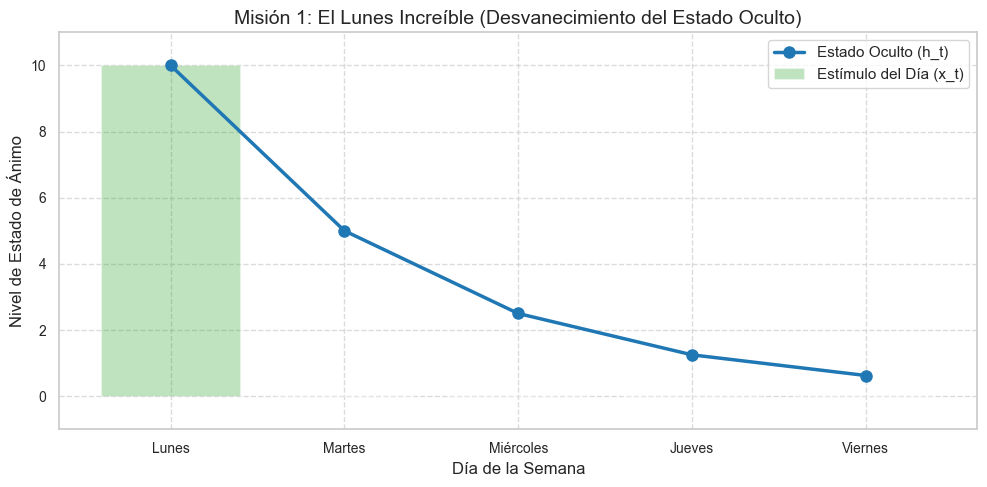

In [2]:
# Eventos para la Misión 1: Lunes (+10), resto de días (0)
eventos_mision1 = np.array([10.0, 0.0, 0.0, 0.0, 0.0])
estados_mision1 = rnn.simular_dias(eventos_mision1)

# Imprimir resultados detallados
print("=== EVOLUCIÓN DEL ESTADO DE ÁNIMO - MISIÓN 1 ===")
for dia, event, state in zip(dias, eventos_mision1, estados_mision1):
    print(f"{dia}: Evento = {event:+.1f} | Estado Final = {state:.4f}")

# Graficar evolución
plt.figure(figsize=(10, 5))
plt.plot(dias, estados_mision1, marker='o', color='#1f77b4', linewidth=2.5, markersize=8, label='Estado Oculto (h_t)')
plt.bar(dias, eventos_mision1, alpha=0.3, color='#2ca02c', label='Estímulo del Día (x_t)')
plt.title("Misión 1: El Lunes Increíble (Desvanecimiento del Estado Oculto)")
plt.xlabel("Día de la Semana")
plt.ylabel("Nivel de Estado de Ánimo")
plt.ylim(-1, 11)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

### Análisis de la Misión 1

Al hacer las cuentas, vemos que el lunes iniciamos muy felices con un diez por el premio. El martes, como no pasó nada nuevo, nos queda la mitad de esa felicidad, o sea un cinco. El miércoles vuelve a caer a la mitad quedando en dos punto cinco, el jueves baja a uno punto veinticinco y para el viernes ya solo nos queda cero punto seiscientos veinticinco de alegría.

Esto demuestra cómo se va perdiendo la memoria con el tiempo. Como multiplicamos lo del día anterior por cero punto cinco cada día, al llegar al viernes ya casi olvidamos por completo lo bueno que fue el lunes. Este es el gran problema de las redes recurrentes simples: no pueden recordar cosas que pasaron hace mucho tiempo si no hay eventos nuevos que las mantengan vivas.

## Misión 2: El Rescate Emocional (Superando el Pasado)

El propósito de esta sección consiste en evaluar y comprender la magnitud del esfuerzo o energía que debe aplicarse para revertir una inercia de memoria negativa que se ha acumulado en el estado de la red. Simulamos un escenario en el cual el Día 1 transcurre con un evento adverso de menos seis unidades por enfermedad, seguido del Día 2 con otro contratiempo de menos cuatro unidades en el entorno laboral. Tras un Día 3 neutro de rutina, se busca calcular qué tan fuerte debe ser el estímulo del Día 4 para lograr que el estado de ánimo al cierre del día vuelva a ser positivo.

Estado acumulado al final del Día 3 (Miércoles): -3.5000
El estímulo del Día 4 debe ser estrictamente mayor que: 1.7500


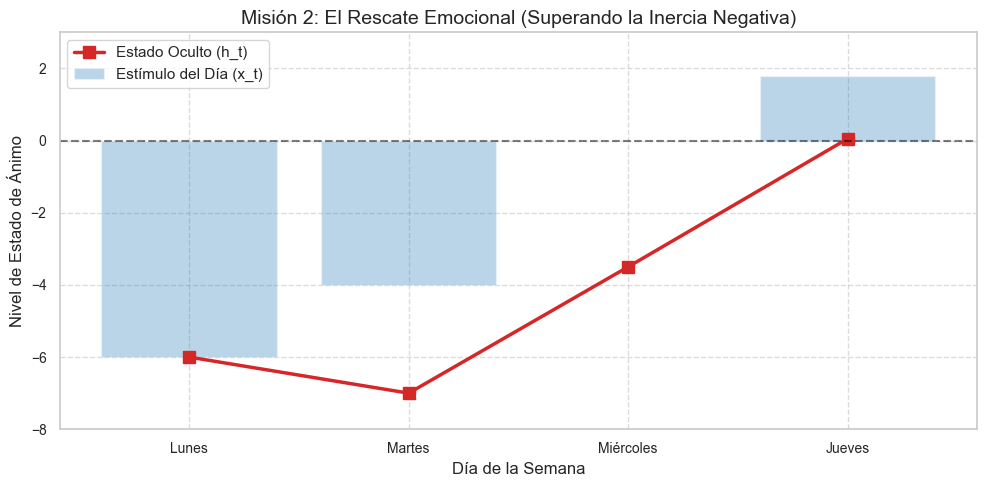

In [3]:
# Eventos acumulados para los días 1, 2 y 3
eventos_mision2_base = np.array([-6.0, -4.0, 0.0])
estados_mision2_base = rnn.simular_dias(eventos_mision2_base)

# Mostrar el estado negativo al final del día 3
h_3 = estados_mision2_base[-1]
print(f"Estado acumulado al final del Día 3 (Miércoles): {h_3:.4f}")

# Calcular el umbral requerido para el Día 4
# h_4 = x_4 + 0.5 * h_3 > 0  =>  x_4 > -0.5 * h_3
x_4_min = -0.5 * h_3
print(f"El estímulo del Día 4 debe ser estrictamente mayor que: {x_4_min:.4f}")

# Simular con un evento que apenas rescata el estado (ej. +1.8) para comprobar la transición a positivo
eventos_rescate = np.array([-6.0, -4.0, 0.0, 1.8])
estados_rescate = rnn.simular_dias(eventos_rescate)

# Graficar el escenario de rescate
plt.figure(figsize=(10, 5))
plt.plot(['Lunes', 'Martes', 'Miércoles', 'Jueves'], estados_rescate, marker='s', color='#d62728', linewidth=2.5, markersize=8, label='Estado Oculto (h_t)')
plt.bar(['Lunes', 'Martes', 'Miércoles', 'Jueves'], eventos_rescate, alpha=0.3, color='#1f77b4', label='Estímulo del Día (x_t)')
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.title("Misión 2: El Rescate Emocional (Superando la Inercia Negativa)")
plt.xlabel("Día de la Semana")
plt.ylabel("Nivel de Estado de Ánimo")
plt.ylim(-8, 3)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

### Análisis de la Misión 2

Aquí las cuentas muestran que el lunes empezamos tristes con menos seis por la enfermedad. El martes nos pasa algo malo en el trabajo y sumamos un menos cuatro, pero como arrastramos la mitad de lo malo del lunes, el estado cae hasta menos siete. El miércoles no pasa nada bueno ni malo, pero seguimos tristes en menos tres punto cinco porque traemos la memoria de los días anteriores.

Para que el jueves nuestro estado de ánimo sea positivo, necesitamos que el evento del día sea mayor que uno punto setenta y cinco. Esto pasa porque la mitad de lo triste que estábamos el miércoles se suma al evento de hoy, así que necesitamos un empuje lo suficientemente fuerte para ganarle a la inercia negativa que venimos arrastrando. En la vida real, esto nos enseña que cuando traemos una mala racha, necesitamos un evento muy bueno para poder cambiar el rumbo y sentirnos bien de nuevo.

## Misión 3: Constancia vs. El Pico (Cómo aprende la red)

El objetivo de esta sección consiste en comparar el impacto a largo plazo de recibir un único estímulo de gran magnitud contra la recepción de estímulos más pequeños pero consistentes y distribuidos temporalmente. Se evalúan dos escenarios distintos. El Escenario A presenta un pico muy alto el Día 1 con una magnitud de más diez unidades, seguido únicamente por valores de cero el resto de la semana. El Escenario B modela una entrada constante de pequeñas alegrías equivalentes a más tres unidades durante cada una de las cinco jornadas de la simulación.

Estado Final del Viernes (Escenario A - Pico): 0.6250
Estado Final del Viernes (Escenario B - Constancia): 5.8125


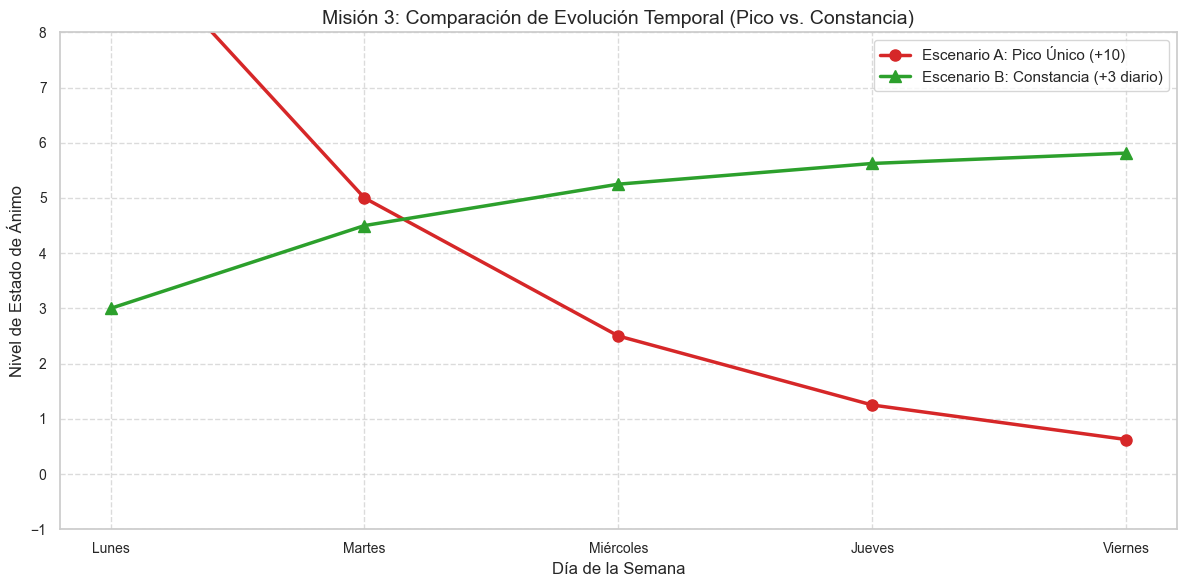

In [4]:
# Escenario A: Pico el día 1 (+10) y luego ceros
eventos_escenarioA = np.array([10.0, 0.0, 0.0, 0.0, 0.0])
estados_escenarioA = rnn.simular_dias(eventos_escenarioA)

# Escenario B: Constancia (+3 todos los días)
eventos_escenarioB = np.array([3.0, 3.0, 3.0, 3.0, 3.0])
estados_escenarioB = rnn.simular_dias(eventos_escenarioB)

# Comparación en el Día 5
print(f"Estado Final del Viernes (Escenario A - Pico): {estados_escenarioA[-1]:.4f}")
print(f"Estado Final del Viernes (Escenario B - Constancia): {estados_escenarioB[-1]:.4f}")

# Graficar comparativa de escenarios
plt.figure(figsize=(12, 6))
plt.plot(dias, estados_escenarioA, marker='o', linestyle='-', color='#d62728', linewidth=2.5, markersize=8, label='Escenario A: Pico Único (+10)')
plt.plot(dias, estados_escenarioB, marker='^', linestyle='-', color='#2ca02c', linewidth=2.5, markersize=8, label='Escenario B: Constancia (+3 diario)')
plt.title("Misión 3: Comparación de Evolución Temporal (Pico vs. Constancia)")
plt.xlabel("Día de la Semana")
plt.ylabel("Nivel de Estado de Ánimo")
plt.ylim(-1, 8)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

### Análisis de la Misión 3

Los resultados nos muestran que el final de la semana es muy diferente en ambos casos. En el Escenario A, aunque empezamos con un evento súper fuerte de diez el lunes, para el viernes casi lo olvidamos todo y terminamos en cero punto seiscientos veinticinco. En cambio, en el Escenario B, al tener pequeñas alegrías de tres todos los días, el estado de ánimo se va acumulando y terminamos el viernes en cinco punto ochocientos doce, que es casi diez veces más alto.

Esto nos dice que las redes recurrentes simples recuerdan mucho mejor las cosas constantes y lo que pasó hace poco. Lo que pasó hace mucho tiempo se borra rápido por el factor de olvido, mientras que los eventos seguidos y recientes se quedan bien guardados. Por eso, este tipo de red le da más importancia a la rutina diaria que a un solo evento del pasado lejano.